In [ ]:
!pip install transformers torch scikit-learn pandas spacy scispacy
# Install SciSpacy model
! pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_md-0.5.4.tar.gz


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.1/119.1 MB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 56.8 MB/s eta 0:00:00
  Created wheel for en_core_sci_md: filename=en_core_sci_md-0.5.4-py3-none-any.whl size=119157918 sha256=1bfbd6b231bab99de5b3d7f7fcdd2df3647d8994709b63ae1f66d98256d2f5a1
  Stored in directory: /root/.cache/pip/wheels/1a/02/d9/4d4bda80f6b73c02ed057d4b3b99abaff286924a80b53c9d68
Successfully built en_core_sci_md
  Attempting uninstall: blis
    Found existing installation: blis 1.3.3
    Uninstalling blis-1.3.3:
      Successfully uninstalled blis-1.3.3
  Attempting uninstall: thinc
    Found existing installation: thinc 8.3.10
    Uninstalling thinc-8.3.10

In [ ]:
import plotly.express as px       # For easy Plotly charts
import plotly.graph_objects as go # For advanced Plotly visualizations
import matplotlib.pyplot as plt   # For Matplotlib plots
import pandas as pd
import numpy as np
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from scipy.sparse import hstack, csr_matrix
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from numpy.lib import scimath

# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# RUN if files are located on your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd "/content/drive/MyDrive/AIHC/data"

/content/drive/MyDrive/AIHC/data


In [ ]:
import pandas as pd

df = pd.read_csv('reddit_depression_dataset.csv')

KeyboardInterrupt: 

Data Analysis for Reditt Depression Data


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2470778 entries, 0 to 2470777
Data columns (total 8 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Unnamed: 0    object 
 1   subreddit     object 
 2   title         object 
 3   body          object 
 4   upvotes       float64
 5   created_utc   float64
 6   num_comments  float64
 7   label         float64
dtypes: float64(4), object(4)
memory usage: 150.8+ MB


In [ ]:
df.head()

,Unnamed: 0,subreddit,title,body,upvotes,created_utc,num_comments,label
0,47951,DeepThoughts,Deep thoughts underdog,"Only when we start considering ourselves, the ...",4.0,1.405309e+09,NaN,0.0
1,47952,DeepThoughts,"I like this sub, there's only two posts yet I ...",Anyway: Human Morality is a joke so long as th...,4.0,1.410568e+09,1.0,0.0
2,47957,DeepThoughts,Rebirth!,Hello. \nI am the new guy in charge here (Besi...,6.0,1.416458e+09,1.0,0.0
3,47959,DeepThoughts,"""I want to be like water. I want to slip throu...",NaN,25.0,1.416512e+09,2.0,0.0
4,47960,DeepThoughts,Who am I?,You could take any one cell in my body and kil...,5.0,1.416516e+09,4.0,0.0


In [ ]:
df.shape

(2470778, 8)

 There is column named Unnamed: 0. This looks more like post_id, so lets rename it


In [ ]:
# rename column Unnamed: 0 as post_id
df.rename(columns={'Unnamed: 0': 'post_id'}, inplace=True)
df.head()

,post_id,subreddit,title,body,upvotes,created_utc,num_comments,label
0,47951,DeepThoughts,Deep thoughts underdog,"Only when we start considering ourselves, the ...",4.0,1.405309e+09,NaN,0.0
1,47952,DeepThoughts,"I like this sub, there's only two posts yet I ...",Anyway: Human Morality is a joke so long as th...,4.0,1.410568e+09,1.0,0.0
2,47957,DeepThoughts,Rebirth!,Hello. \nI am the new guy in charge here (Besi...,6.0,1.416458e+09,1.0,0.0
3,47959,DeepThoughts,"""I want to be like water. I want to slip throu...",NaN,25.0,1.416512e+09,2.0,0.0
4,47960,DeepThoughts,Who am I?,You could take any one cell in my body and kil...,5.0,1.416516e+09,4.0,0.0


Calculate records where body is null


In [ ]:
#count records where body is null or NaN
df['body'].isnull().sum()

np.int64(461051)

Out of 2470778 records 461051 have no text on the post. this is about 18% of the post. We can safely remove those frfom our data

In [ ]:
#remove records from df where body is null or empty
df = df.dropna(subset=['body'])
df.shape

(2009727, 8)

In [ ]:
#check how many Label is na or null and remove those
df['label'].isnull().sum()

np.int64(84)

In [ ]:
df = df.dropna(subset=['label'])

Lets see the distribution of label. lebel=0 means depression not detected. label=1 means depression detected


In [ ]:
#distribution of label in df
df['label'].value_counts()

,count
label,
0.0,1547897
1.0,461746


In [ ]:
#distribution of subreddit in df
df['subreddit'].value_counts()

,count
subreddit,
teenagers,1525849
depression,282390
SuicideWatch,179356
happy,15206
DeepThoughts,6842


Lets plot the distribution in a pie chart

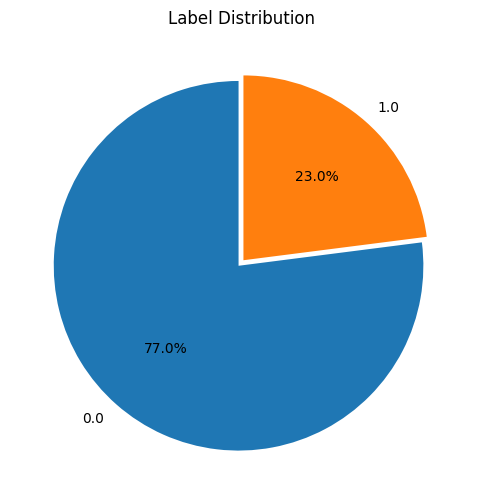

In [ ]:
plt.figure(figsize=(6,6))
label_counts = df['label'].value_counts().sort_index()
label_counts.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.02]*len(label_counts)
)

plt.title("Label Distribution")
plt.ylabel("")
plt.show()

since we have time distribution of this data. lets see the timeseries distribution of this data\

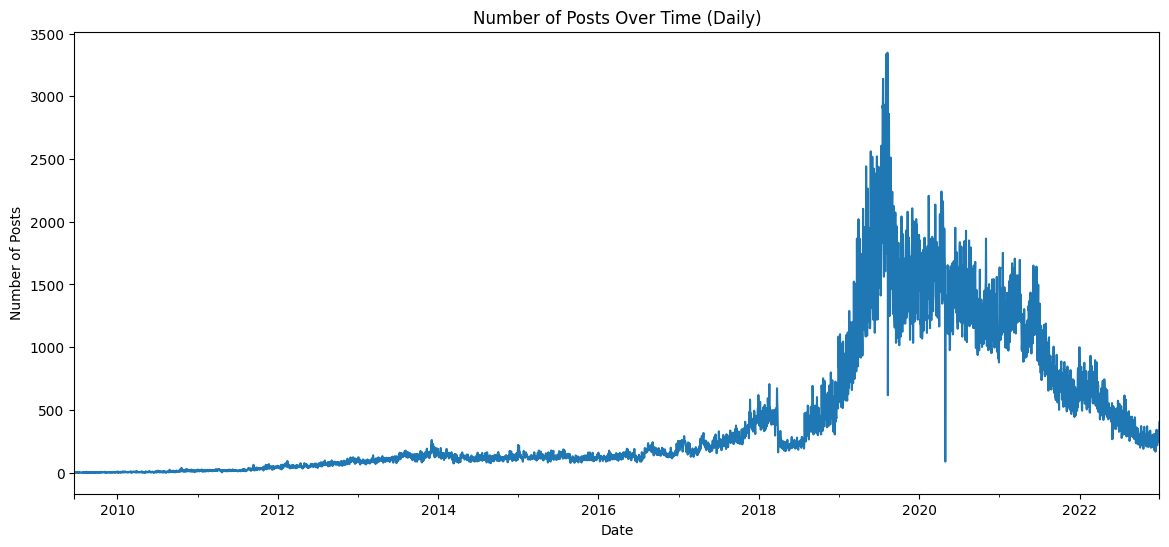

In [ ]:
#convert created_utc to datetime
df['datetime'] = pd.to_datetime(df['created_utc'], unit='s')
#plot timeseries
daily_counts = df.set_index('datetime').resample('D').size()

plt.figure(figsize=(14,6))
daily_counts.plot()

plt.title("Number of Posts Over Time (Daily)")
plt.xlabel("Date")
plt.ylabel("Number of Posts")
plt.show()


this data is distributed uniformly from 2010 to 2023. Except there is spike in 2019 and 2020. this is understandable as this was Covid period with lockdown in almost every part of the world. this increased the depression cases

In [ ]:
# Check if there is any duplicate
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2009643 entries, 0 to 2470777
Data columns (total 9 columns):
 #   Column        Dtype         
---  ------        -----         
 0   post_id       object        
 1   subreddit     object        
 2   title         object        
 3   body          object        
 4   upvotes       float64       
 5   created_utc   float64       
 6   num_comments  float64       
 7   label         float64       
 8   datetime      datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 153.3+ MB


Lets check the distribution of subreddit. As per kaggle documentation
It encompasses data from six specific subreddits:



*   Teenagers
*   Depression
*   SuicideWatch
*   DeepThoughts
*   Happy

















In [ ]:
df['subreddit'].value_counts()

,count
subreddit,
teenagers,1525849
depression,282390
SuicideWatch,179356
happy,15206
DeepThoughts,6842


Also lets do some type conversion for the columns for better performance and memory optimization


In [ ]:
# convert text columns
df['title'] = df['title'].astype('string')
df['body'] = df['body'].astype('string')

# numeric optimizations
df['upvotes'] = df['upvotes'].fillna(0).astype('int32')
df['num_comments'] = df['num_comments'].fillna(0).astype('int32')

# timestamp conversion
df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s')

# label optimization
df['label'] = df['label'].astype('int8')
df['post_id'] = df['post_id'].astype('int64')
# convert subreddit to category
df['subreddit'] = df['subreddit'].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2009643 entries, 0 to 2470777
Data columns (total 9 columns):
 #   Column        Dtype         
---  ------        -----         
 0   post_id       int64         
 1   subreddit     category      
 2   title         string        
 3   body          string        
 4   upvotes       int32         
 5   created_utc   datetime64[ns]
 6   num_comments  int32         
 7   label         int8          
 8   datetime      datetime64[ns]
dtypes: category(1), datetime64[ns](2), int32(2), int64(1), int8(1), string(2)
memory usage: 111.2 MB


Distribution of subreddit

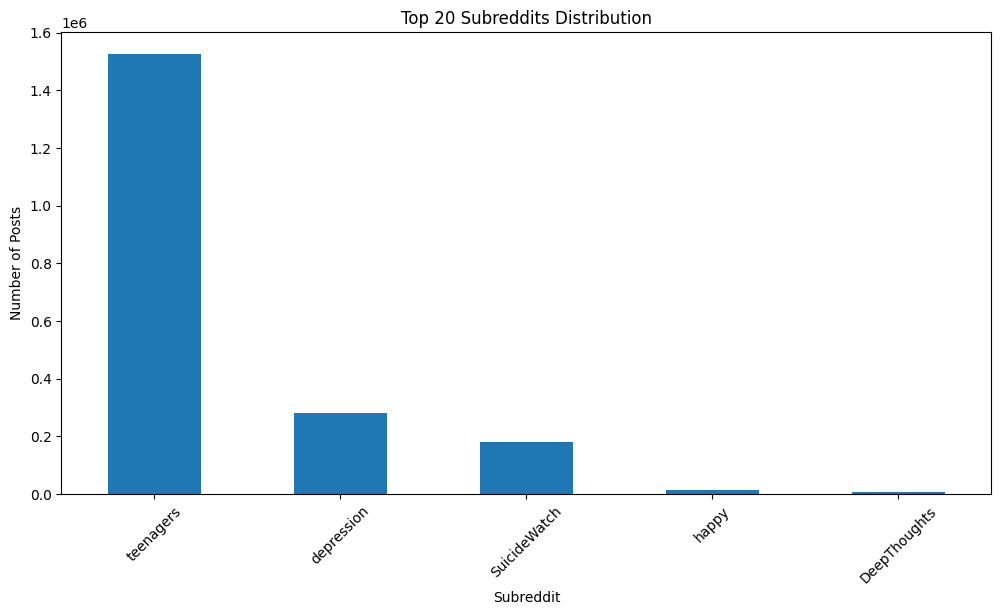

In [ ]:
v_subreddits = df['subreddit'].value_counts()

plt.figure(figsize=(12,6))
v_subreddits.plot(kind='bar')

plt.title("Top 20 Subreddits Distribution")
plt.xlabel("Subreddit")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.show()

Lets see heatmap

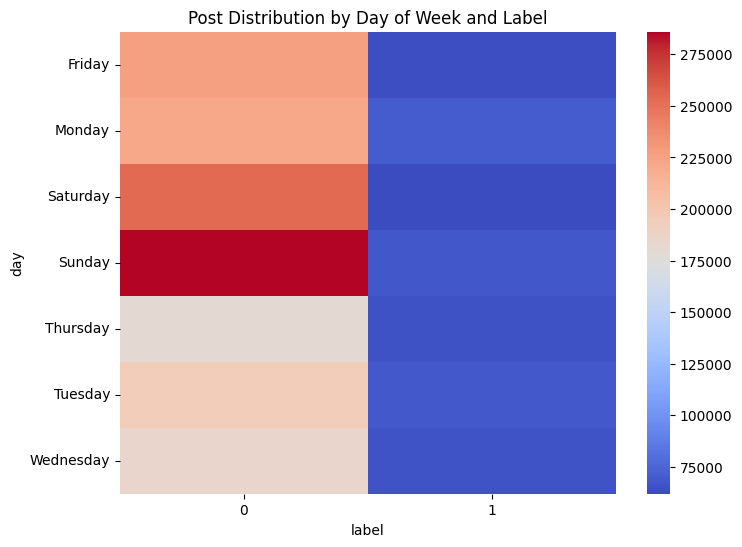

In [ ]:
df['day'] = df['created_utc'].dt.day_name()

heat = df.groupby(['day','label']).size().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(heat, cmap='coolwarm')

plt.title("Post Distribution by Day of Week and Label")
plt.show()

the strongest activity is seen on weekends.


Avergae updates for each label

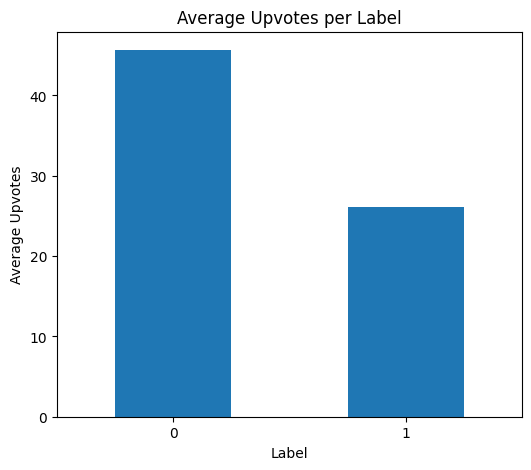

In [ ]:
avg_upvotes = df.groupby('label')['upvotes'].mean()

plt.figure(figsize=(6,5))
avg_upvotes.plot(kind='bar')

plt.title("Average Upvotes per Label")
plt.xlabel("Label")
plt.ylabel("Average Upvotes")
plt.xticks(rotation=0)

plt.show()

More upvotes on non depression post. THis meand that people relate more to non depressivve votes.

Average number of comments per label

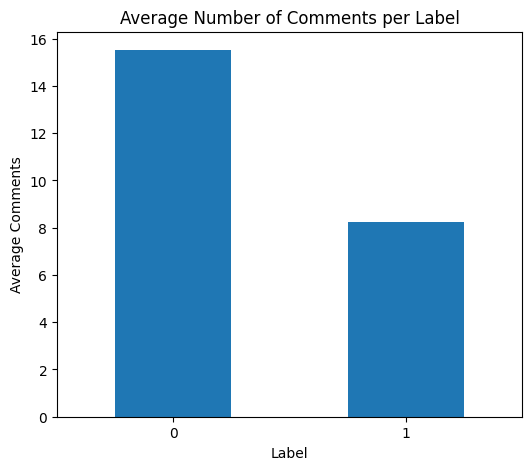

In [ ]:
avg_comments = df.groupby('label')['num_comments'].mean()

plt.figure(figsize=(6,5))
avg_comments.plot(kind='bar')

plt.title("Average Number of Comments per Label")
plt.xlabel("Label")
plt.ylabel("Average Comments")
plt.xticks(rotation=0)

plt.show()

More comments are seen on non depression post

Average comment wordsize for each label

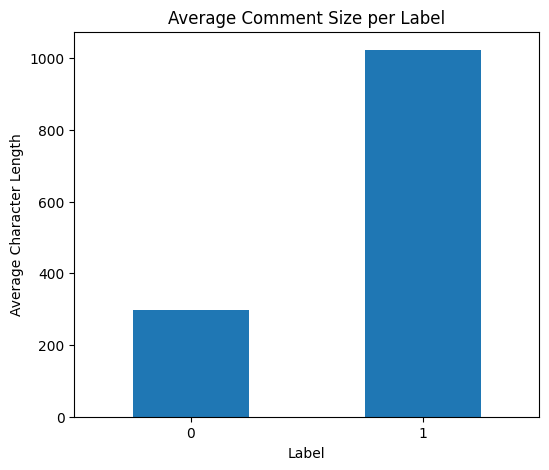

In [ ]:
df['comment_size'] = df['body'].str.len()
avg_size = df.groupby('label')['comment_size'].mean()

plt.figure(figsize=(6,5))
avg_size.plot(kind='bar')

plt.title("Average Comment Size per Label")
plt.xlabel("Label")
plt.ylabel("Average Character Length")
plt.xticks(rotation=0)

plt.show()

We can see the average comments size on depressive post are much more than non depressive post. Which means even if depressive post get less comment but those comments are very lengthy. This shows compassion of viewers are engaging more with depressed posts

In [ ]:
def clean_text(text):
    # Tokenize the text into words
    words = text.split()

    # Remove special characters and convert to lowercase
    clean_words = [word.lower() for word in words if word.isalnum()]

    # Remove stopwords
    stop_words = set(stopwords.words("english"))
    filtered_words = [word for word in clean_words if word not in stop_words]

    # Remove words with less than 4 characters and numbers. This is done in order to reduce noisy data and numbers dont contribute much in any NLP applications
    filtered_words = [word for word in filtered_words if len(word) >= 4 and not word.isdigit()]

    # Remove duplicate words
    cleaned_text = " ".join(dict.fromkeys(filtered_words))  # This is useful while plotting t-SNE plots

    return cleaned_text

In [ ]:
#add a new column clean_body which is result of clean_text function by passing the body
df['clean_body'] = df['body'].apply(clean_text)


In [ ]:
# export data in df in a csv named optimized_reditt_depression_data.csv
df.to_csv('optimized_reddit_depression_data.csv', index=False)

# Transformer-Based Depression Detection from Social Media
### Using ClinicalBERT + Medical Entity Recognition

This notebook demonstrates how to build a depression detection model using:
- Reddit Depression Dataset (social media posts)
- ClinicalBERT transformer model
- Medical Named Entity Recognition (SciSpacy)

Pipeline:
1. Load dataset
2. Clean text
3. Extract medical entities
4. Generate ClinicalBERT embeddings
5. Combine entity features + text embeddings
6. Train depression classification model

## 1. Install Dependencies

In [ ]:
#read optimized_reddit_depression_data in dataframe - o_df
o_df = pd.read_csv('optimized_reddit_depression_data.csv')
o_df.head()

,post_id,subreddit,title,body,upvotes,created_utc,num_comments,label,datetime,day,comment_size,clean_body
0,47951,DeepThoughts,Deep thoughts underdog,"Only when we start considering ourselves, the ...",4,2014-07-14 03:35:09,0,0,2014-07-14 03:35:09,Monday,138,start considering begin value starting rooting
1,47952,DeepThoughts,"I like this sub, there's only two posts yet I ...",Anyway: Human Morality is a joke so long as th...,4,2014-09-13 00:31:19,1,0,2014-09-13 00:31:19,Saturday,97,human morality joke long abscence deep thought
2,47957,DeepThoughts,Rebirth!,Hello. \nI am the new guy in charge here (Besi...,6,2014-11-20 04:31:58,1,0,2014-11-20 04:31:58,Thursday,253,charge thegood bring know best keep subreddit
3,47960,DeepThoughts,Who am I?,You could take any one cell in my body and kil...,5,2014-11-20 20:36:52,4,0,2014-11-20 20:36:52,Thursday,2095,could take cell body kill would still network ...
4,47969,DeepThoughts,What is the limit of the knowledge and power a...,"Personally, I think it's infinite. We will alw...",8,2014-11-22 19:17:39,23,0,2014-11-22 19:17:39,Saturday,55,think always


In [ ]:
o_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2009643 entries, 0 to 2009642
Data columns (total 12 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   post_id       int64 
 1   subreddit     object
 2   title         object
 3   body          object
 4   upvotes       int64 
 5   created_utc   object
 6   num_comments  int64 
 7   label         int64 
 8   datetime      object
 9   day           object
 10  comment_size  int64 
 11  clean_body    object
dtypes: int64(5), object(7)
memory usage: 184.0+ MB


Change the type of columns for optimization like before

In [ ]:
# convert text columns
o_df['title'] = o_df['title'].astype('string')
o_df['body'] = o_df['body'].astype('string')
o_df['clean_body'] = o_df['body'].astype('string')

# numeric optimizations
o_df['upvotes'] = o_df['upvotes'].fillna(0).astype('int32')
o_df['num_comments'] = o_df['num_comments'].fillna(0).astype('int32')

# timestamp conversion
o_df['created_utc'] = pd.to_datetime(o_df['created_utc'])

# label optimization
o_df['label'] = o_df['label'].astype('int8')
o_df['post_id'] = o_df['post_id'].astype('int64')
# convert subreddit to category
o_df['subreddit'] = o_df['subreddit'].astype('category')

Entity Recognition using SciSpacy

In [ ]:
import spacy

nlp_sci = spacy.load('en_core_sci_md')

/usr/local/lib/python3.12/dist-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


In [ ]:
import pandas as pd

def process_entities_checkpoint(
        df,
        text_col="clean_body",
        id_col="post_id",
        batch_size=300,
        chunk_size=10000,
        resume_post_id=None,
        output_file="entities_checkpoint.csv"
    ):

    # sort for deterministic processing
    df = df.sort_values(id_col).reset_index(drop=True)

    # resume logic
    if resume_post_id is not None:
        start_index = df[df[id_col] >= resume_post_id].index[0]
    else:
        start_index = 0

    total = len(df)

    for start in range(start_index, total, chunk_size):

        end = min(start + chunk_size, total)
        chunk = df.iloc[start:end]

        print(f"\nProcessing rows {start} → {end} (post_id {chunk[id_col].iloc[0]} → {chunk[id_col].iloc[-1]})")

        entities = []

        for doc in nlp_sci.pipe(
                chunk[text_col],
                batch_size=batch_size,
                disable=["tagger", "parser", "lemmatizer"]
        ):
            entities.append(" ".join(ent.text for ent in doc.ents))

        # store in dataframe
        df.loc[start:end-1, "entities"] = entities

        # save checkpoint
        chunk_output = df.loc[start:end-1, [id_col, text_col, "entities"]]

        chunk_output.to_csv(
            output_file,
            mode="a",
            header=not pd.io.common.file_exists(output_file),
            index=False
        )

        print(f"Saved checkpoint for rows {start}-{end}")

    return df

In [ ]:


# def extract_entities(text):
#     doc = nlp(text)
#     return [ent.text for ent in doc.ents]
# def extract_entities_scispacy(text_series, batch_size=100):
#     results = []

#     for doc in nlp_sci.pipe(text_series, batch_size=batch_size):
#         entities = [(ent.text, ent.label_) for ent in doc.ents]
#         results.append(entities)

#     return results
# import time

# def extract_entities_scispacy(text_series, batch_size=1000):
#     results = []
#     total = len(text_series)
#     start = time.time()

#     for i, doc in enumerate(
#         nlp_sci.pipe(
#             text_series,
#             batch_size=batch_size,
#             disable=["tagger", "parser", "lemmatizer"]
#         )
#     ):
#         # extract only entity text
#         entities = " ".join(ent.text for ent in doc.ents)
#         results.append(entities)

#         # progress print
#         if (i + 1) % batch_size == 0 or (i + 1) == total:
#             elapsed = time.time() - start
#             percent = (i + 1) / total * 100
#             print(f"Processed {i+1}/{total} ({percent:.2f}%)")

#     return results


In [ ]:
test_df = o_df.head(1000).copy()
test_checkpoint = "entities_test_checkpoint.csv"
import os

if os.path.exists(test_checkpoint):
    os.remove(test_checkpoint)
test_df, last_post_id = load_checkpoint(test_df, test_checkpoint)
test_df = process_entities_checkpoint(
    test_df,
    resume_post_id=last_post_id,
    batch_size=50,
    chunk_size=200,
    output_file=test_checkpoint
)
test_df[['post_id','entities']].head()


No checkpoint found. Starting fresh.

Processing rows 0 → 200 (post_id 47951 → 48677)
Saved checkpoint for rows 0-200

Processing rows 200 → 400 (post_id 48683 → 49440)
Saved checkpoint for rows 200-400

Processing rows 400 → 600 (post_id 49443 → 50042)
Saved checkpoint for rows 400-600

Processing rows 600 → 800 (post_id 50043 → 50632)
Saved checkpoint for rows 600-800

Processing rows 800 → 1000 (post_id 50634 → 51086)
Saved checkpoint for rows 800-1000


,post_id,entities
0,47951,rooting
1,47952,Human Morality abscence day
2,47957,TheGood ofc WeirdPineapple subreddit
3,47960,cell body kill I kill cells network cells work...
4,47969,Personally infinite grow


In [ ]:
pd.read_csv(test_checkpoint).head()

,post_id,clean_body,entities
0,47951,"Only when we start considering ourselves, the ...",rooting
1,47952,Anyway: Human Morality is a joke so long as th...,Human Morality abscence day
2,47957,Hello. \nI am the new guy in charge here (Besi...,TheGood ofc WeirdPineapple subreddit
3,47960,You could take any one cell in my body and kil...,cell body kill I kill cells network cells work...
4,47969,"Personally, I think it's infinite. We will alw...",Personally infinite grow


In [ ]:
test_df, last_post_id = load_checkpoint(test_df, test_checkpoint)

test_df = process_entities_checkpoint(
    test_df,
    resume_post_id=last_post_id,
    batch_size=50,
    chunk_size=200,
    output_file=test_checkpoint
)

Loading checkpoint file...
Checkpoint rows: 1000
Last processed post_id: 51086

Processing rows 999 → 1000 (post_id 51086 → 51086)
Saved checkpoint for rows 999-1000


In [ ]:
o_df = process_entities_checkpoint(o_df)


Processing rows 0 → 10000 (post_id 47951 → 519495)
Saved checkpoint for rows 0-10000

Processing rows 10000 → 20000 (post_id 519496 → 550114)
Saved checkpoint for rows 10000-20000

Processing rows 20000 → 30000 (post_id 550115 → 592941)
Saved checkpoint for rows 20000-30000

Processing rows 30000 → 40000 (post_id 592944 → 662507)
Saved checkpoint for rows 30000-40000

Processing rows 40000 → 50000 (post_id 662509 → 733264)
Saved checkpoint for rows 40000-50000

Processing rows 50000 → 60000 (post_id 733270 → 785035)
Saved checkpoint for rows 50000-60000

Processing rows 60000 → 70000 (post_id 785042 → 825285)
Saved checkpoint for rows 60000-70000

Processing rows 70000 → 80000 (post_id 825286 → 860207)
Saved checkpoint for rows 70000-80000

Processing rows 80000 → 90000 (post_id 860208 → 893000)
Saved checkpoint for rows 80000-90000

Processing rows 90000 → 100000 (post_id 893004 → 931072)
Saved checkpoint for rows 90000-100000

Processing rows 100000 → 110000 (post_id 931074 → 974045

This process takes lot of time and sometimes due to memory crashes in between. ISince we have defined a checkoiint where entities are getting stored for every 10000 chiunks incrementally. we can first load the checkpoint file and rehydrate entities directly from this into o_df (main dataframe ). So we do not need to start from the beginning. this is being done through load_checkpoint function

In [ ]:
clean_rows = 1700000

checkpoint_df = pd.read_csv(
    "entities_checkpoint.csv",
    nrows=clean_rows,
    engine="python"
)

print("Loaded rows:", len(checkpoint_df))

Loaded rows: 1700000


In [ ]:
clean_checkpoint = "entities_checkpoint_clean_filtered.csv"

checkpoint_df.to_csv(
    clean_checkpoint,
    index=False
)

print("Clean checkpoint saved:", clean_checkpoint)

Clean checkpoint saved: entities_checkpoint_clean_filtered.csv


In [ ]:
import os

In [ ]:
def load_checkpoint(o_df, checkpoint_file="entities_checkpoint_clean_filtered.csv"):

    if os.path.exists(checkpoint_file):
        print("Loading checkpoint file...")

        checkpoint_df = pd.read_csv(checkpoint_file)

        print("Checkpoint rows:", len(checkpoint_df))

        # merge entities back into dataframe
        o_df = o_df.merge(
            checkpoint_df[['post_id','entities']],
            on='post_id',
            how='left'
        )

        last_post_id = checkpoint_df['post_id'].max()

        print("Last processed post_id:", last_post_id)

        return o_df, last_post_id

    else:
        print("No checkpoint found. Starting fresh.")
        o_df['entities'] = None
        return o_df, None

In [ ]:
checkpoint_file = "entities_checkpoint_clean_filtered.csv"
o_df, last_post_id = load_checkpoint(o_df, checkpoint_file)

o_df = process_entities_checkpoint(
    o_df,
    resume_post_id=last_post_id,
    batch_size=300,
    chunk_size=10000,
    output_file=checkpoint_file
)

print("Processing complete.")

Loading checkpoint file...
Checkpoint rows: 1700000
Last processed post_id: 9177916

Processing rows 1719999 → 1729999 (post_id 9177916 → 9232219)
Saved checkpoint for rows 1719999-1729999

Processing rows 1729999 → 1739999 (post_id 9232221 → 9259224)
Saved checkpoint for rows 1729999-1739999

Processing rows 1739999 → 1749999 (post_id 9259225 → 9292046)
Saved checkpoint for rows 1739999-1749999

Processing rows 1749999 → 1759999 (post_id 9292047 → 9326393)
Saved checkpoint for rows 1749999-1759999

Processing rows 1759999 → 1769999 (post_id 9326394 → 9368311)
Saved checkpoint for rows 1759999-1769999

Processing rows 1769999 → 1779999 (post_id 9368312 → 9409236)
Saved checkpoint for rows 1769999-1779999

Processing rows 1779999 → 1789999 (post_id 9409246 → 9456489)
Saved checkpoint for rows 1779999-1789999

Processing rows 1789999 → 1799999 (post_id 9456492 → 9503604)
Saved checkpoint for rows 1789999-1799999

Processing rows 1799999 → 1809999 (post_id 9503607 → 9551222)
Saved checkpo

Test resume functionality

Pretend the process crashed after row 400.

Run again:

test_df = process_entities_checkpoint(
    test_df,
    resume_post_id=test_df.iloc[400]['post_id'],
    output_file="entities_test_checkpoint.csv"
)

In [ ]:
checkpoint_df = pd.read_csv("entities_checkpoint.csv")
o_df = o_df.merge(
    checkpoint_df[['post_id','entities']],
    on='post_id',
    how='left'
)


In [ ]:
o_df.to_csv('entity_opt_reddit_depression_data.csv', index=False)

In [ ]:
#extract the post_id and clean_body where entity is null in a separate csv
new_df = o_df[o_df['entities'].isnull()]
#save post_id and clean_body from new_df in a csv file - no_entity_retry.csv
new_df[['post_id','clean_body']].to_csv('no_entity_retry.csv', index=False)

In [ ]:
#read no_entity_retry.csv
new_df = pd.read_csv('no_entity_retry.csv')
new_df.shape

(163815, 2)

In [ ]:
new_df = process_entities_checkpoint(new_df)


Processing rows 0 → 10000 (post_id 48040 → 1125882)
Saved checkpoint for rows 0-10000

Processing rows 10000 → 20000 (post_id 1125946 → 1612241)
Saved checkpoint for rows 10000-20000

Processing rows 20000 → 30000 (post_id 1612311 → 2050991)
Saved checkpoint for rows 20000-30000

Processing rows 30000 → 40000 (post_id 2051246 → 2451060)
Saved checkpoint for rows 30000-40000

Processing rows 40000 → 50000 (post_id 2451124 → 2850956)
Saved checkpoint for rows 40000-50000

Processing rows 50000 → 60000 (post_id 2851066 → 3282934)
Saved checkpoint for rows 50000-60000

Processing rows 60000 → 70000 (post_id 3283025 → 3698053)
Saved checkpoint for rows 60000-70000

Processing rows 70000 → 80000 (post_id 3698060 → 4085296)
Saved checkpoint for rows 70000-80000

Processing rows 80000 → 90000 (post_id 4085297 → 4866178)
Saved checkpoint for rows 80000-90000

Processing rows 90000 → 100000 (post_id 4866212 → 5603969)
Saved checkpoint for rows 90000-100000

Processing rows 100000 → 110000 (post

In [ ]:
new_df['entities'].isnull().sum()

0

In [ ]:
o_df = pd.read_csv('entity_opt_reddit_depression_data.csv')
o_df.head()

,post_id,subreddit,title,body,upvotes,created_utc,num_comments,label,datetime,day,comment_size,clean_body,entities
0,47951,DeepThoughts,Deep thoughts underdog,"Only when we start considering ourselves, the ...",4,2014-07-14 03:35:09,0,0,2014-07-14 03:35:09,Monday,138,"Only when we start considering ourselves, the ...",rooting
1,47952,DeepThoughts,"I like this sub, there's only two posts yet I ...",Anyway: Human Morality is a joke so long as th...,4,2014-09-13 00:31:19,1,0,2014-09-13 00:31:19,Saturday,97,Anyway: Human Morality is a joke so long as th...,Human Morality abscence day
2,47957,DeepThoughts,Rebirth!,Hello. \nI am the new guy in charge here (Besi...,6,2014-11-20 04:31:58,1,0,2014-11-20 04:31:58,Thursday,253,Hello. \nI am the new guy in charge here (Besi...,TheGood ofc WeirdPineapple subreddit
3,47960,DeepThoughts,Who am I?,You could take any one cell in my body and kil...,5,2014-11-20 20:36:52,4,0,2014-11-20 20:36:52,Thursday,2095,You could take any one cell in my body and kil...,cell body kill I kill cells network cells work...
4,47969,DeepThoughts,What is the limit of the knowledge and power a...,"Personally, I think it's infinite. We will alw...",8,2014-11-22 19:17:39,23,0,2014-11-22 19:17:39,Saturday,55,"Personally, I think it's infinite. We will alw...",Personally infinite grow


In [ ]:
o_df['entities'].isnull().sum()

163815

In [ ]:
# merge o_df and new_df on post_id and copy entities from new_df into o_df
entity_map = new_df.set_index('post_id')['entities']

o_df.loc[o_df['entities'].isna(), 'entities'] = (
    o_df.loc[o_df['entities'].isna(), 'post_id'].map(entity_map)
)
o_df['entities'].isnull().sum()

0

In [ ]:
o_df.to_csv('entity_final_reddit_depression_data.csv', index=False)

## 2. Load Dataset
Dataset format expected:

| text | label |
|-----|------|
| Reddit post | 0/1 |

In [ ]:
o_df = pd.read_csv('entity_final_reddit_depression_data.csv')
o_df.head()

,post_id,subreddit,title,body,upvotes,created_utc,num_comments,label,datetime,day,comment_size,clean_body,entities
0,47951,DeepThoughts,Deep thoughts underdog,"Only when we start considering ourselves, the ...",4,2014-07-14 03:35:09,0,0,2014-07-14 03:35:09,Monday,138,"Only when we start considering ourselves, the ...",rooting
1,47952,DeepThoughts,"I like this sub, there's only two posts yet I ...",Anyway: Human Morality is a joke so long as th...,4,2014-09-13 00:31:19,1,0,2014-09-13 00:31:19,Saturday,97,Anyway: Human Morality is a joke so long as th...,Human Morality abscence day
2,47957,DeepThoughts,Rebirth!,Hello. \nI am the new guy in charge here (Besi...,6,2014-11-20 04:31:58,1,0,2014-11-20 04:31:58,Thursday,253,Hello. \nI am the new guy in charge here (Besi...,TheGood ofc WeirdPineapple subreddit
3,47960,DeepThoughts,Who am I?,You could take any one cell in my body and kil...,5,2014-11-20 20:36:52,4,0,2014-11-20 20:36:52,Thursday,2095,You could take any one cell in my body and kil...,cell body kill I kill cells network cells work...
4,47969,DeepThoughts,What is the limit of the knowledge and power a...,"Personally, I think it's infinite. We will alw...",8,2014-11-22 19:17:39,23,0,2014-11-22 19:17:39,Saturday,55,"Personally, I think it's infinite. We will alw...",Personally infinite grow


In [ ]:
# convert text columns
o_df['title'] = o_df['title'].astype('string')
o_df['body'] = o_df['body'].astype('string')
o_df['clean_body'] = o_df['body'].astype('string')

# numeric optimizations
o_df['upvotes'] = o_df['upvotes'].fillna(0).astype('int32')
o_df['num_comments'] = o_df['num_comments'].fillna(0).astype('int32')

# timestamp conversion
o_df['created_utc'] = pd.to_datetime(o_df['created_utc'])

# label optimization
o_df['label'] = o_df['label'].astype('int8')
o_df['post_id'] = o_df['post_id'].astype('int64')
# convert subreddit to category
o_df['subreddit'] = o_df['subreddit'].astype('category')
o_df['entities'] = o_df['entities'].astype('string')

Load ClinicalBERT

In [ ]:
!pip install transformers torch tqdm

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
from sentence_transformers import SentenceTransformer


#for checkpoint
TARGET_SIZE = 100000
LABEL_RATIO = {0: 0.6, 1: 0.4}

df = o_df.copy()

df["created_utc"] = pd.to_datetime(df["created_utc"])
df["year"] = df["created_utc"].dt.year

df = df.dropna(subset=["entities", "label"])

target_counts = {
    0: int(TARGET_SIZE * LABEL_RATIO[0]),
    1: int(TARGET_SIZE * LABEL_RATIO[1])
}

samples = []

for label, target in target_counts.items():

    df_label = df[df["label"] == label]

    years = sorted(df_label["year"].unique())

    per_year = target // len(years)

    for year in years:

        df_year = df_label[df_label["year"] == year]

        if len(df_year) == 0:
            continue

        n = min(len(df_year), per_year)

        sample = df_year.sample(n=n, random_state=42)

        samples.append(sample)

sampled_df = pd.concat(samples)

remaining = TARGET_SIZE - len(sampled_df)

if remaining > 0:

    extra = (
        df.drop(sampled_df.index)
        .sample(n=remaining, random_state=42)
    )

    sampled_df = pd.concat([sampled_df, extra])

sampled_df = sampled_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Sampled dataset size:", len(sampled_df))
print(sampled_df["label"].value_counts())
print(sampled_df["year"].value_counts().sort_index())

#prepare for ebedding
sampled_df["text"] = (
    sampled_df["title"].fillna("") + " " +
    sampled_df["clean_body"].fillna("") + " " +
    sampled_df["entities"].fillna("")
)
#Load Sentence transformer model
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
CHECKPOINT_FILE = "pruned_st_post_embeddings_checkpoint.pkl"

BATCH_SIZE = 512
SAVE_INTERVAL = 2000

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

model = SentenceTransformer(MODEL_NAME, device=device)

#prepare data
data = (
    sampled_df.loc[:, ["post_id", "text"]]
    .drop_duplicates("post_id")
    .sort_values("post_id")
)

post_ids = data["post_id"].tolist()
texts = data["text"].tolist()
#load checkpoint
embedding_map = {}

if os.path.exists(CHECKPOINT_FILE):

    with open(CHECKPOINT_FILE, "rb") as f:
        embedding_map = pickle.load(f)

    last_checkpoint = max(embedding_map.keys())
    print("Resuming from checkpoint. Last saved post_id:", last_checkpoint)

else:
    print("No checkpoint found. Starting fresh.")

processed_ids = set(embedding_map.keys())

remaining_data = [
    (pid, txt) for pid, txt in zip(post_ids, texts)
    if pid not in processed_ids
]

print("Remaining posts to process:", len(remaining_data))
#embedding with checkpoint
counter = 0

for i in tqdm(range(0, len(remaining_data), BATCH_SIZE)):

    batch = remaining_data[i:i+BATCH_SIZE]

    batch_ids = [x[0] for x in batch]
    batch_texts = [x[1] for x in batch]

    batch_embeddings = model.encode(
        batch_texts,
        batch_size=BATCH_SIZE,
        convert_to_numpy=True,
        show_progress_bar=False
    )

    for pid, emb in zip(batch_ids, batch_embeddings):
        embedding_map[pid] = emb

    counter += len(batch_ids)

    if counter >= SAVE_INTERVAL:

        with open(CHECKPOINT_FILE, "wb") as f:
            pickle.dump(embedding_map, f)

        print("Checkpoint saved. Last post_id:", batch_ids[-1])

        counter = 0

#Save
with open(CHECKPOINT_FILE, "wb") as f:
    pickle.dump(embedding_map, f)

print("Embedding generation complete.")
print("Total embeddings:", len(embedding_map))

Sampled dataset size: 100000
label
0    59335
1    40665
Name: count, dtype: int64
year
2009      488
2010     3072
2011     4249
2012     7269
2013     7408
2014     7407
2015     7428
2016     7459
2017     7768
2018     8096
2019    10672
2020    10757
2021     9639
2022     8288
Name: count, dtype: int64
Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Resuming from checkpoint. Last saved post_id: 10741870
Remaining posts to process: 95189


  2%|▏         | 4/186 [01:09<52:42, 17.37s/it]

...

Checkpoint saved. Last post_id: 10386160


 99%|█████████▉| 184/186 [56:07<00:44, 22.39s/it]

Checkpoint saved. Last post_id: 10627098


100%|██████████| 186/186 [56:38<00:00, 18.27s/it]


Embedding generation complete.
Total embeddings: 100189


In [ ]:
sampled_df.to_csv('pruned_embedding_final_reddit_depression_data.csv', index=False)



---

########################################


---



**Now we can train a Classifier model using Neural net. this model takes the data and embedding , pass it to model and MLP will do the prediction. It will also print the classification report and provide the accuracy of the model.**

In [ ]:
sampled_df = pd.read_csv('pruned_embedding_final_reddit_depression_data.csv')

Feature shape: (100000, 768)
Epoch 1 Loss: 0.3305
Epoch 2 Loss: 0.2713
Epoch 3 Loss: 0.2582
Epoch 4 Loss: 0.2503
Epoch 5 Loss: 0.2446
Epoch 6 Loss: 0.2409
Epoch 7 Loss: 0.2367
Epoch 8 Loss: 0.2333
Epoch 9 Loss: 0.2307
Epoch 10 Loss: 0.2282
Epoch 11 Loss: 0.2251
Epoch 12 Loss: 0.2229
Epoch 13 Loss: 0.2210
Epoch 14 Loss: 0.2176
Epoch 15 Loss: 0.2173
Epoch 16 Loss: 0.2139
Epoch 17 Loss: 0.2124
Epoch 18 Loss: 0.2104
Epoch 19 Loss: 0.2094
Epoch 20 Loss: 0.2072
Epoch 21 Loss: 0.2049
Epoch 22 Loss: 0.2029
Epoch 23 Loss: 0.2023
Epoch 24 Loss: 0.2010
Epoch 25 Loss: 0.1996
Epoch 26 Loss: 0.1972
Epoch 27 Loss: 0.1948
Epoch 28 Loss: 0.1942
Epoch 29 Loss: 0.1932
Epoch 30 Loss: 0.1914


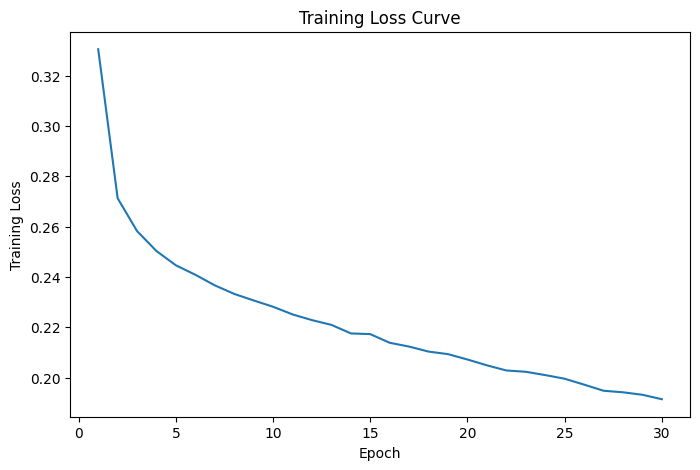

              precision    recall  f1-score   support

           0       0.90      0.95      0.93     11867
           1       0.92      0.85      0.88      8133

    accuracy                           0.91     20000
   macro avg       0.91      0.90      0.90     20000
weighted avg       0.91      0.91      0.91     20000



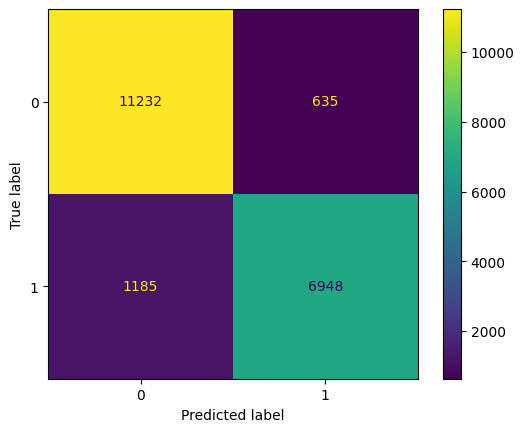

In [ ]:
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#load embeddings from previously saved file

with open("pruned_st_post_embeddings_checkpoint.pkl", "rb") as f:
    embedding_map = pickle.load(f)

sampled_df["embedding"] = sampled_df["post_id"].map(embedding_map)

sampled_df = sampled_df.dropna(subset=["embedding"])

#build feature matrices

X = np.vstack(sampled_df["embedding"].values)
#labels
y = sampled_df["label"].values

print("Feature shape:", X.shape)

#train test split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#prepare pytorch Dataset
class EmbeddingDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = EmbeddingDataset(X_train, y_train)
val_dataset = EmbeddingDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

#define model architecture

class Classifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 64),
            nn.ReLU(),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)


model = Classifier()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

#define training parameters

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

#start training the model with 30 epochs and plot loss

epochs = 30
loss_history = []

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

##plotting

plt.figure(figsize=(8,5))

plt.plot(range(1, epochs+1), loss_history)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")

plt.show()

#check model accuracy by eval

model.eval()

preds = []
truth = []

with torch.no_grad():

    for X_batch, y_batch in val_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        pred = torch.argmax(outputs, dim=1).cpu().numpy()

        preds.extend(pred)
        truth.extend(y_batch.numpy())

print(classification_report(truth, preds))

#prepare confusion matrix

ConfusionMatrixDisplay.from_predictions(truth, preds)

plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer
import torch
import pandas as pd

#load model
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

device = "cuda" if torch.cuda.is_available() else "cpu"

embed_model = SentenceTransformer(MODEL_NAME, device=device)

# -----------------------------------------
# Example test posts
# -----------------------------------------

test_posts = [
"I haven't slept properly for a week and my anxiety keeps getting worse.",
"I feel overwhelmed and mentally drained all the time.",
"I can't stop worrying about everything and it's affecting my work.",
"My anxiety wakes me up every night and I can't calm my thoughts.",
"I feel like I'm falling apart mentally and nothing seems to help.",
"I am feeling great today and went hiking with friends.",
"Had a productive day at work and finished my project.",
"I'm excited for the weekend and planning to travel.",
"I cooked dinner and watched a movie tonight.",
"I met some friends today and had a good time."
]

#Generate embeddings
embeddings = embed_model.encode(
    test_posts,
    convert_to_numpy=True
)

embeddings_tensor = torch.tensor(embeddings).float().to(device)

#predict labels

model.eval()

with torch.no_grad():

    logits = model(embeddings_tensor)

    probabilities = torch.softmax(logits, dim=1)

    predicted_labels = torch.argmax(probabilities, dim=1).cpu().numpy()

probs = probabilities.cpu().numpy()

#report

report_df = pd.DataFrame({
    "text": test_posts,
    "predicted_label": predicted_labels,
    "prob_label0": probs[:,0],
    "prob_label1": probs[:,1]
})

print(report_df)

#summary statistics

print("\nPrediction distribution:")
print(report_df["predicted_label"].value_counts())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


                                                text  predicted_label  \
0  I haven't slept properly for a week and my anx...                0   
1  I feel overwhelmed and mentally drained all th...                1   
2  I can't stop worrying about everything and it'...                1   
3  My anxiety wakes me up every night and I can't...                1   
4  I feel like I'm falling apart mentally and not...                1   
5  I am feeling great today and went hiking with ...                0   
6  Had a productive day at work and finished my p...                0   
7  I'm excited for the weekend and planning to tr...                0   
8       I cooked dinner and watched a movie tonight.                0   
9      I met some friends today and had a good time.                0   

   prob_label0  prob_label1  
0     0.867914     0.132086  
1     0.415749     0.584251  
2     0.220514     0.779486  
3     0.046830     0.953170  
4     0.012631     0.987369  
5     0.985151  